# Baltimore Port Trade: Exploratory Data Analysis

## Project Goal

This project studies the causal impact of the Francis Scott Key Bridge collapse on trade activity at the Port of Baltimore.

The bridge collapsed on March 26, 2024. Because the collapse occurred near the end of March, April 2024 will be treated as the first full post-treatment month.

Before estimating causal effects, I first examine Baltimore's trade data over time and check the quality of the dataset.

## Load the Data

I use monthly Baltimore port data to study whether trade changed after the bridge collapse.

April 2024 is the first full treatment month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/baltimore_imports.csv")

df.head()

,general_import_value,vessel_import_value,vessel_import_weight,port_name,month,port_code
0,3467100521,3439162614,1213524503,"BALTIMORE, MD",2019-01,1303
1,3527773923,3503063676,1120493870,"BALTIMORE, MD",2019-02,1303
2,3740442889,3719890098,1063839057,"BALTIMORE, MD",2019-03,1303
3,4150203282,4139140781,1075456430,"BALTIMORE, MD",2019-04,1303
4,4001267270,3991269456,1197129890,"BALTIMORE, MD",2019-05,1303


## Data Check

Before estimating a causal effect, I check that the monthly data are complete and that the treatment period is correctly identified.

The bridge collapsed on March 26, 2024, so April 2024 is the first full treatment month.

In [2]:
df.shape

(91, 6)

In [3]:
df.isna().sum()

general_import_value    0
vessel_import_value     0
vessel_import_weight    0
port_name               0
month                   0
port_code               0
dtype: int64

In [4]:
# Convert month to a date
df["month"] = pd.to_datetime(df["month"])

In [5]:
df[
    (df["month"] >= "2024-01-01") &
    (df["month"] <= "2024-07-01")
][["month", "vessel_import_value", "vessel_import_weight"]]

,month,vessel_import_value,vessel_import_weight
60,2024-01-01,4722395537,1140315385
61,2024-02-01,4080443640,1030690605
62,2024-03-01,4545638792,1017694205
63,2024-04-01,1444669628,301460189
64,2024-05-01,2469053607,505991025
65,2024-06-01,3161018816,660253264
66,2024-07-01,4110759129,805117123


## Initial Evidence

Baltimore's vessel imports dropped sharply in April 2024, the first full month after the bridge collapse.

From March to April:

- Vessel import value fell by about 68%.
- Vessel import weight fell by about 70%.

Trade began to recover in the following months.


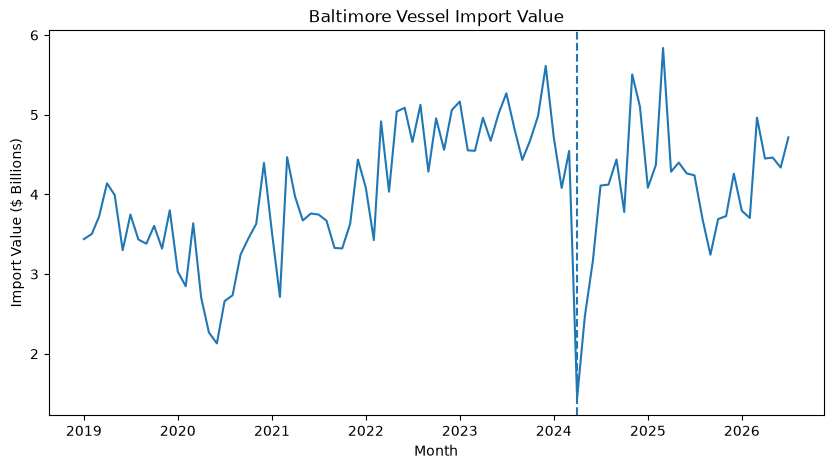

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(df["month"], df["vessel_import_value"] / 1e9)

plt.axvline(pd.Timestamp("2024-04-01"), linestyle="--")

plt.title("Baltimore Vessel Import Value")
plt.xlabel("Month")
plt.ylabel("Import Value ($ Billions)")

plt.show()

## Interpretation

Baltimore vessel imports show a sharp drop in April 2024, immediately after the bridge collapse.

The drop is much larger than most normal month-to-month changes in the pre-treatment period.

However, Baltimore also shows strong volatility and a rising pre-treatment trend. A simple before-after comparison is not enough for causal inference.

The next step is to build a counterfactual using other U.S. ports.